In [1]:
#SP23-BDS-039 NAYAB KHALID #SP23-BDS-040 NOOR UL HUDA BATOOL 

In [2]:
#BIG DATA LAB PROJECT 

In [3]:
#MIDTERM PART

In [4]:
#SPARK SESSION

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NetflixBigDataProject") \
    .master("local[*]") \
    .config("spark.sql.warehouse.dir","hdfs://localhost:9000/user/hive/warehouse") \
    .enableHiveSupport() \
    .getOrCreate()

In [5]:
spark.sql("SHOW DATABASES").show()

+---------+
|namespace|
+---------+
|  default|
+---------+



In [6]:
#READ DATA FROM HDFS

df = spark.read.csv(
    "hdfs://localhost:9000/netflix_project/netflix_titles.csv",
    header=True,
    inferSchema=True
)

In [7]:
df.show(5)

+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|show_id|   type|               title|       director|                cast|      country|        date_added|release_year|rating| duration|           listed_in|         description|
+-------+-------+--------------------+---------------+--------------------+-------------+------------------+------------+------+---------+--------------------+--------------------+
|     s1|  Movie|Dick Johnson Is Dead|Kirsten Johnson|                NULL|United States|September 25, 2021|        2020| PG-13|   90 min|       Documentaries|As her father nea...|
|     s2|TV Show|       Blood & Water|           NULL|Ama Qamata, Khosi...| South Africa|September 24, 2021|        2021| TV-MA|2 Seasons|International TV ...|After crossing pa...|
|     s3|TV Show|           Ganglands|Julien Leclercq|Sami Bouajila, Tr...|         NULL|Septem

In [8]:
df.printSchema()

root
 |-- show_id: string (nullable = true)
 |-- type: string (nullable = true)
 |-- title: string (nullable = true)
 |-- director: string (nullable = true)
 |-- cast: string (nullable = true)
 |-- country: string (nullable = true)
 |-- date_added: string (nullable = true)
 |-- release_year: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- listed_in: string (nullable = true)
 |-- description: string (nullable = true)



In [9]:
#CLEAN NULL VALUES

df = df.fillna({
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown",
    "rating": "Not Rated"
})

In [10]:
#REMOVE DUPLICATES
df = df.dropDuplicates()

In [11]:
#ADD DERIVED COLUMNS
from pyspark.sql.functions import *

In [12]:
#Convert date:
df = df.withColumn(
    "date_added",
    to_date(col("date_added"), "MMMM d, yyyy")
)

In [13]:
#Create year/month:
df = df.withColumn(
    "added_year",
    year("date_added")
)

df = df.withColumn(
    "added_month",
    month("date_added")
)

In [14]:
#Create content age:
df = df.withColumn(
    "content_age",
    year(current_date()) - col("release_year")
)

In [15]:
df.show(5)

+-------+-------+--------------------+--------------------+--------------------+--------------------+----------+------------+------+--------+--------------------+--------------------+----------+-----------+-----------+
|show_id|   type|               title|            director|                cast|             country|date_added|release_year|rating|duration|           listed_in|         description|added_year|added_month|content_age|
+-------+-------+--------------------+--------------------+--------------------+--------------------+----------+------------+------+--------+--------------------+--------------------+----------+-----------+-----------+
|   s122|TV Show|      Hotel Del Luna|             Unknown|Lee Ji-eun, Yeo J...|             Unknown|2021-09-02|        2019| TV-14|1 Season|International TV ...|When he's invited...|      2021|          9|        7.0|
|   s461|  Movie|           Surf's Up|Ash Brannon, Chri...|Shia LaBeouf, Jef...|United States, Ca...|2021-07-15|        2007

In [16]:
#SAVE CLEAN DATA TO HDFS

df.write.mode("overwrite").parquet(
    "hdfs://localhost:9000/netflix_project/cleaned_data"
)

In [17]:
spark.sql("DROP TABLE IF EXISTS netflix_data")

DataFrame[]

In [18]:
#CREATE HIVE TABLE
spark.sql("""
CREATE EXTERNAL TABLE netflix_data (
    show_id STRING,
    type STRING,
    title STRING,
    director STRING,
    cast STRING,
    country STRING,
    date_added DATE,
    release_year STRING,
    rating STRING,
    duration STRING,
    listed_in STRING,
    description STRING,
    added_year INT,
    added_month INT,
    content_age INT
)
STORED AS PARQUET
LOCATION 'hdfs://localhost:9000/netflix_project/cleaned_data'
""")

DataFrame[]

In [19]:
#VERIFY TABLE
spark.sql("SHOW TABLES").show()

+---------+------------+-----------+
|namespace|   tableName|isTemporary|
+---------+------------+-----------+
|  default|netflix_data|      false|
+---------+------------+-----------+



In [20]:
#HIVE QUERIES

In [21]:
#QUERY 1 — Count Movies vs TV Shows
spark.sql("""
SELECT type, COUNT(*) as total_content
FROM netflix_data
GROUP BY type
""").show()

+-------------+-------------+
|         type|total_content|
+-------------+-------------+
|         NULL|            1|
|      TV Show|         2676|
|        Movie|         6131|
|William Wyler|            1|
+-------------+-------------+



In [22]:
#QUERY 2 — Top Categories
spark.sql("""
SELECT listed_in, COUNT(*) as total
FROM netflix_data
GROUP BY listed_in
ORDER BY total DESC
LIMIT 10
""").show()

+--------------------+-----+
|           listed_in|total|
+--------------------+-----+
|Dramas, Internati...|  361|
|       Documentaries|  358|
|     Stand-Up Comedy|  334|
|Comedies, Dramas,...|  273|
|Dramas, Independe...|  252|
|            Kids' TV|  220|
|Children & Family...|  215|
|Children & Family...|  201|
|Documentaries, In...|  186|
|Dramas, Internati...|  180|
+--------------------+-----+



In [23]:
#QUERY 3 — Filter Recent Content

spark.sql("""
SELECT title, release_year
FROM netflix_data
WHERE release_year >= 2020
""").show()

+--------------------+------------+
|               title|release_year|
+--------------------+------------+
|    The Paper Tigers|        2021|
|Car Masters: Rust...|        2021|
|  My Unorthodox Life|        2021|
|          Mama Drama|        2020|
|Super Monsters: O...|        2021|
|  Tuesdays & Fridays|        2021|
|Age of Samurai: B...|        2021|
|                Pelé|        2021|
| Pretend It’s a City|        2021|
| Dream Home Makeover|        2021|
|             Monarca|        2021|
|Natalie Palamides...|        2020|
|The Trials of Gab...|        2020|
|       Ghost Stories|        2020|
|            Carnaval|        2021|
|      I Am All Girls|        2021|
|Reframe THEATER E...|        2020|
|        Mr. Iglesias|        2020|
|               Hoops|        2020|
|All the Freckles ...|        2020|
+--------------------+------------+
only showing top 20 rows



In [24]:
#QUERY 4 — Top 10 Countries with Most Netflix Content
spark.sql("""
SELECT country, COUNT(*) AS total_content
FROM netflix_data
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_content DESC
LIMIT 10
""").show()

+--------------+-------------+
|       country|total_content|
+--------------+-------------+
| United States|         2805|
|         India|          972|
|       Unknown|          832|
|United Kingdom|          419|
|         Japan|          245|
|   South Korea|          199|
|        Canada|          181|
|         Spain|          145|
|        France|          123|
|        Mexico|          110|
+--------------+-------------+



In [25]:
#QUERY 5 — Number of Movies and TV Shows Released Each Year
spark.sql("""
SELECT release_year, type, COUNT(*) AS total_titles
FROM netflix_data
GROUP BY release_year, type
ORDER BY release_year DESC
""").show()

+-----------------+-------------+------------+
|     release_year|         type|total_titles|
+-----------------+-------------+------------+
|    United States|        Movie|           1|
|    June 12, 2021|        Movie|           1|
| January 15, 2021|        Movie|           1|
| January 13, 2021|        Movie|           1|
|December 15, 2020|      TV Show|           1|
|  August 13, 2020|        Movie|           1|
|           40 min|William Wyler|           1|
|             2021|        Movie|         275|
|             2021|      TV Show|         314|
|             2020|      TV Show|         436|
|             2020|        Movie|         516|
|             2019|        Movie|         630|
|             2019|      TV Show|         396|
|             2018|        Movie|         765|
|             2018|      TV Show|         380|
|             2017|      TV Show|         265|
|             2017|        Movie|         765|
|             2016|      TV Show|         244|
|            

In [26]:
#FINAL PART

In [27]:
#VERIFYING IF TABLE EXISTS
spark.sql("SHOW TABLES").show()

+---------+------------+-----------+
|namespace|   tableName|isTemporary|
+---------+------------+-----------+
|  default|netflix_data|      false|
+---------+------------+-----------+



In [28]:
#IMPORTING REQUIRED LIBRARIES
from pyspark.sql.functions import *
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import pandas as pd

In [29]:
# Advanced Analytics in Spark


In [30]:
# 1. YEARLY CONTENT GROWTH ANALYSIS

In [31]:
growth_df = spark.sql("""
SELECT 
CAST(release_year AS INT) AS year,
COUNT(*) AS total_titles
FROM netflix_data
GROUP BY release_year
ORDER BY year
""")

In [32]:
windowSpec = Window.orderBy("year")

In [33]:
growth_df = growth_df.withColumn(
    "previous_year",
    lag("total_titles").over(windowSpec)
)

In [34]:
growth_df = growth_df.withColumn(
    "growth_rate",
    round(
        (
            (col("total_titles") - col("previous_year"))
            / col("previous_year")
        ) * 100,
        2
    )
)

In [35]:
growth_df.show()

+----+------------+-------------+-----------+
|year|total_titles|previous_year|growth_rate|
+----+------------+-------------+-----------+
|NULL|           1|         NULL|       NULL|
|NULL|           1|            1|        0.0|
|NULL|           2|            1|      100.0|
|NULL|           1|            2|      -50.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1|        0.0|
|NULL|           1|            1| 

In [36]:
# 2. CONTENT SEGMENTATION
# (behavior grouping)

In [37]:
content_segments = df.withColumn(
    "content_segment",
    when(col("content_age") <= 5, "Recent")
    .when(col("content_age") <= 15, "Modern")
    .otherwise("Classic")
)

In [38]:
segment_counts = content_segments.groupBy(
    "content_segment"
).count()

In [39]:
segment_counts.show()

+---------------+-----+
|content_segment|count|
+---------------+-----+
|         Modern| 6675|
|         Recent|  589|
|        Classic| 1545|
+---------------+-----+



In [40]:
# 3. MONTHLY CONTENT ADDITION TREND
# (time-based aggregation)

In [41]:
monthly_trend = spark.sql("""
SELECT
added_month,
COUNT(*) AS total_added
FROM netflix_data
GROUP BY added_month
ORDER BY added_month
""")

In [42]:
monthly_trend.show()

+-----------+-----------+
|added_month|total_added|
+-----------+-----------+
|       NULL|        120|
|          1|        722|
|          2|        557|
|          3|        732|
|          4|        757|
|          5|        625|
|          6|        723|
|          7|        818|
|          8|        746|
|          9|        763|
|         10|        754|
|         11|        696|
|         12|        796|
+-----------+-----------+



In [43]:
# 4. COUNTRY + GENRE ANALYSIS
# (Category Level)

In [44]:
country_genre = spark.sql("""
SELECT 
country,
listed_in,
COUNT(*) AS total
FROM netflix_data
WHERE country IS NOT NULL
GROUP BY country, listed_in
ORDER BY total DESC
""")

In [45]:
country_genre.show(20, truncate=False)

+-------------+----------------------------------------------------------+-----+
|country      |listed_in                                                 |total|
+-------------+----------------------------------------------------------+-----+
|United States|Documentaries                                             |248  |
|United States|Stand-Up Comedy                                           |209  |
|India        |Comedies, Dramas, International Movies                    |120  |
|India        |Dramas, International Movies                              |118  |
|India        |Dramas, Independent Movies, International Movies          |108  |
|United States|Children & Family Movies, Comedies                        |90   |
|United States|Dramas                                                    |88   |
|United States|Comedies                                                  |84   |
|United States|Children & Family Movies                                  |80   |
|United States|Kids' TV     

In [46]:
#DIRECTOR PRODUCTIVITY ANALYSIS

In [47]:
director_analysis = spark.sql("""
SELECT
director,
COUNT(*) AS total_titles
FROM netflix_data
WHERE director != 'Unknown'
GROUP BY director
ORDER BY total_titles DESC
LIMIT 15
""")

In [48]:
director_analysis.show(truncate=False)

+----------------------+------------+
|director              |total_titles|
+----------------------+------------+
|Rajiv Chilaka         |19          |
|Raúl Campos, Jan Suter|18          |
|Marcus Raboy          |16          |
|Suhas Kadav           |16          |
|Jay Karas             |14          |
|Cathy Garcia-Molina   |13          |
|Youssef Chahine       |12          |
|Martin Scorsese       |12          |
|Jay Chapman           |12          |
|Steven Spielberg      |11          |
|Don Michael Paul      |10          |
|David Dhawan          |9           |
|Robert Rodriguez      |8           |
|Troy Miller           |8           |
|Kunle Afolayan        |8           |
+----------------------+------------+



In [49]:
# HBASE SECTION

In [50]:
#CREATING HBASE METRICS DATAFRAME
hbase_metrics = spark.sql("""
SELECT
country,
COUNT(*) AS total_titles,
MAX(listed_in) AS dominant_genre
FROM netflix_data
GROUP BY country
ORDER BY total_titles DESC
""")

In [51]:
hbase_metrics.show()

+--------------------+------------+--------------------+
|             country|total_titles|      dominant_genre|
+--------------------+------------+--------------------+
|       United States|        2805|           Thrillers|
|               India|         972|            TV Shows|
|             Unknown|         832|           Thrillers|
|      United Kingdom|         419|           Thrillers|
|               Japan|         245|            TV Shows|
|         South Korea|         199|     Stand-Up Comedy|
|              Canada|         181|           Thrillers|
|               Spain|         145|           Thrillers|
|              France|         123|     Stand-Up Comedy|
|              Mexico|         110|     Stand-Up Comedy|
|               Egypt|         106|International TV ...|
|              Turkey|         105|International TV ...|
|             Nigeria|          93|International TV ...|
|           Australia|          87|           Thrillers|
|              Taiwan|         

In [52]:
#EXPORT HBASE METRICS
hbase_metrics.toPandas().to_csv(
    "C:/NetflixFinalProject/hbase_metrics.csv",
    index=False
)

In [53]:
# Join Hive + HBase 

In [54]:
hbase_df = spark.read.csv(
    "C:/NetflixFinalProject/hbase_metrics.csv",
    header=True,
    inferSchema=True
)

In [55]:
hbase_df.show()

+--------------------+------------+--------------------+
|             country|total_titles|      dominant_genre|
+--------------------+------------+--------------------+
|       United States|        2805|           Thrillers|
|               India|         972|            TV Shows|
|             Unknown|         832|           Thrillers|
|      United Kingdom|         419|           Thrillers|
|               Japan|         245|            TV Shows|
|         South Korea|         199|     Stand-Up Comedy|
|              Canada|         181|           Thrillers|
|               Spain|         145|           Thrillers|
|              France|         123|     Stand-Up Comedy|
|              Mexico|         110|     Stand-Up Comedy|
|               Egypt|         106|International TV ...|
|              Turkey|         105|International TV ...|
|             Nigeria|          93|International TV ...|
|           Australia|          87|           Thrillers|
|              Taiwan|         

In [56]:
hbase_df.createOrReplaceTempView("hbase_metrics")

In [57]:
joined_df = spark.sql("""
SELECT
n.title,
n.country,
n.rating,
h.total_titles,
h.dominant_genre
FROM netflix_data n
JOIN hbase_metrics h
ON n.country = h.country
""")

In [58]:
#VIEW JOINED RESULT
joined_df.show()

+--------------------+--------------------+------+------------+--------------------+
|               title|             country|rating|total_titles|      dominant_genre|
+--------------------+--------------------+------+------------+--------------------+
|    The Paper Tigers|       United States| PG-13|        2805|           Thrillers|
|Car Masters: Rust...|             Unknown| TV-PG|         832|           Thrillers|
|Chhota Bheem & Kr...|             Unknown| TV-Y7|         832|           Thrillers|
|  My Unorthodox Life|             Unknown| TV-MA|         832|           Thrillers|
|          Mama Drama|             Unknown| TV-MA|         832|           Thrillers|
|   A Haunted House 2|       United States|     R|        2805|           Thrillers|
|Super Monsters: O...|             Unknown|  TV-Y|         832|           Thrillers|
|          Legal Hash|             Unknown| TV-MA|         832|           Thrillers|
|  Tuesdays & Fridays|               India| TV-14|         972|  

In [59]:
# VISUALIZATIONS

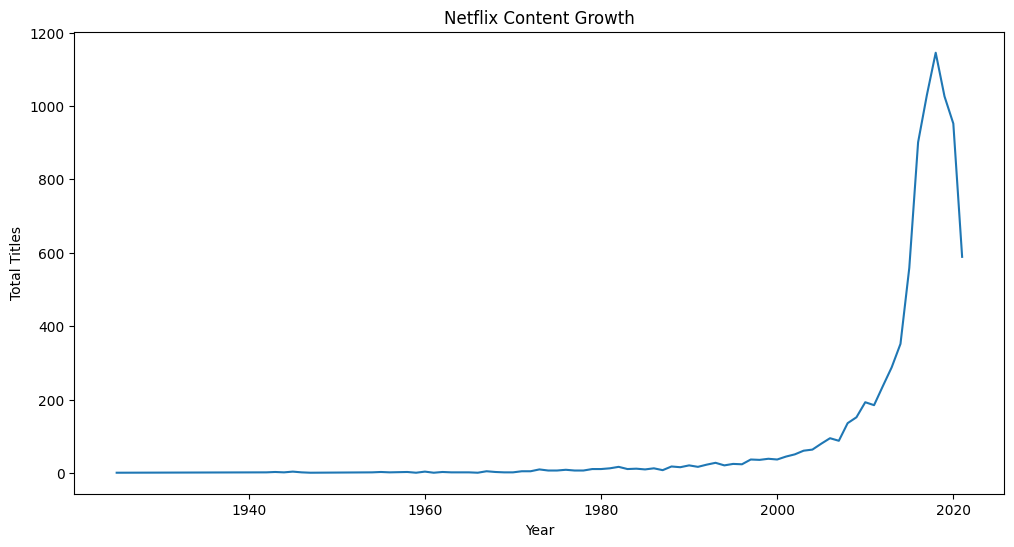

In [60]:
# 1. GROWTH RATE THROUGH LINE CHART
growth_pd = growth_df.toPandas()

plt.figure(figsize=(12,6))

plt.plot(
    growth_pd["year"],
    growth_pd["total_titles"]
)

plt.title("Netflix Content Growth")
plt.xlabel("Year")
plt.ylabel("Total Titles")

plt.show()

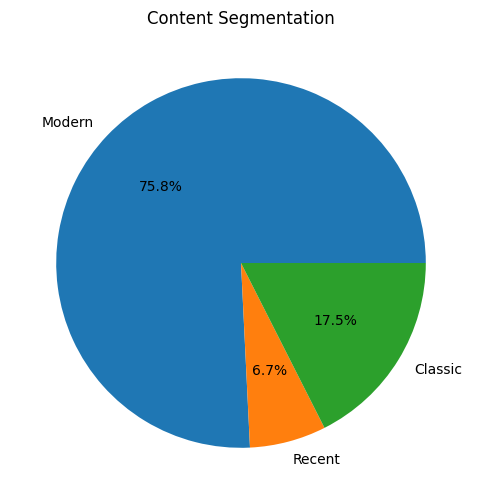

In [61]:
# 2. CONTENT SEGMENTS THROUGH PIE CHART
segment_pd = segment_counts.toPandas()

plt.figure(figsize=(6,6))

plt.pie(
    segment_pd["count"],
    labels=segment_pd["content_segment"],
    autopct='%1.1f%%'
)

plt.title("Content Segmentation")

plt.show()

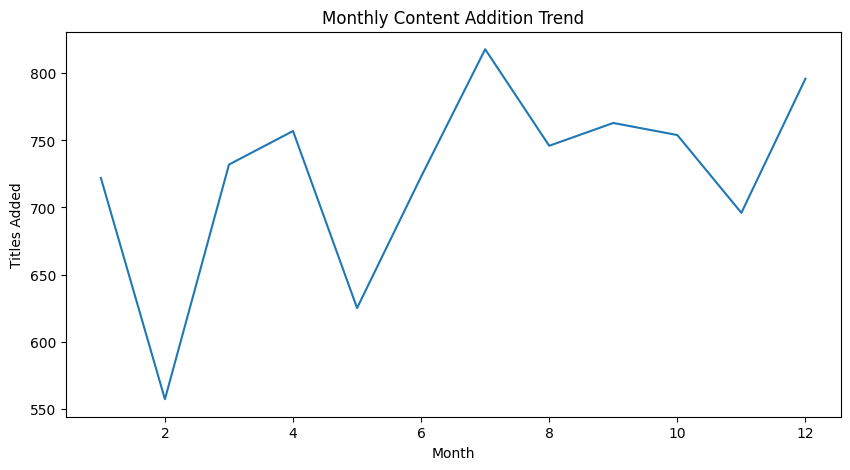

In [62]:
# 3. MONTHLY TREND THROUGH LINE CHART
monthly_pd = monthly_trend.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pd["added_month"],
    monthly_pd["total_added"]
)

plt.title("Monthly Content Addition Trend")
plt.xlabel("Month")
plt.ylabel("Titles Added")

plt.show()

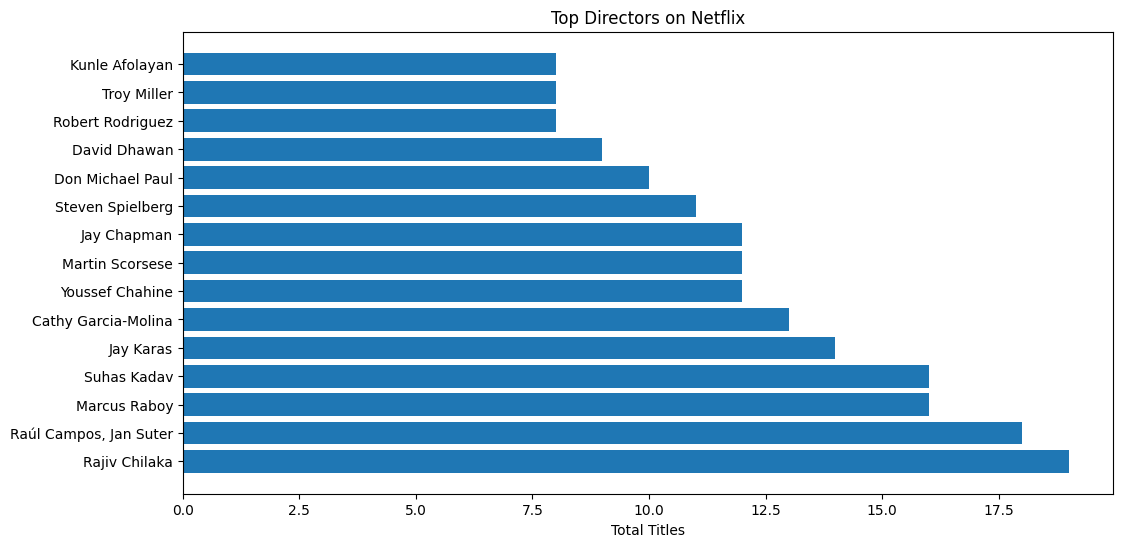

In [63]:
# 4. DIRECTOR ANALYSIS THOUGH HORIZONTAL BAR CHART 
director_pd = director_analysis.toPandas()

plt.figure(figsize=(12,6))

plt.barh(
    director_pd["director"],
    director_pd["total_titles"]
)

plt.title("Top Directors on Netflix")
plt.xlabel("Total Titles")

plt.show()

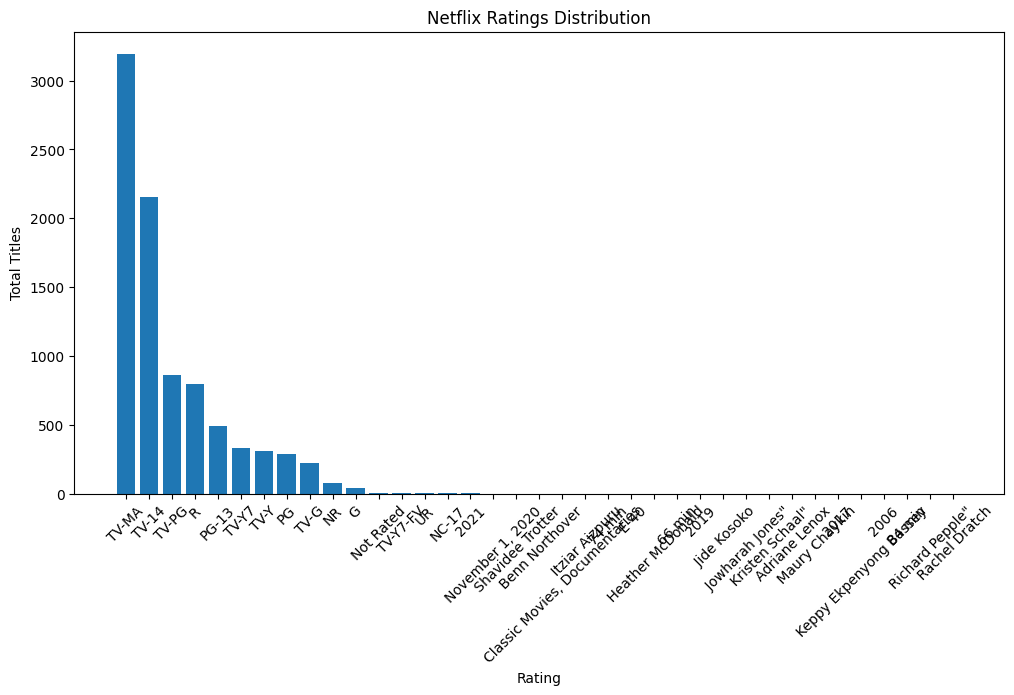

In [64]:
# 5. RATINGS DISTRIBUTION CHART THROUGH BAR CHART 

ratings = spark.sql("""
SELECT
rating,
COUNT(*) AS total
FROM netflix_data
GROUP BY rating
ORDER BY total DESC
""")
ratings_pd = ratings.toPandas()

plt.figure(figsize=(12,6))

plt.bar(
    ratings_pd["rating"],
    ratings_pd["total"]
)

plt.title("Netflix Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Total Titles")

plt.xticks(rotation=45)

plt.show()